Lab01 DL
1. Sử dụng bộ dữ liệu CIFAR 100. Có thể sử dụng dataloader hoặc các phương pháp đọc dữ liệu khác của torch.
2. Phân tách thành 2 hàm chính: hàm train, hàm predict để thực thi huấn luyện và dự báo kết quả.
3. Sử dụng phương pháp KNN với k=5 hoặc 7 để thực thi quá trình phân lớp ảnh theo 2 hàm train và predict ở trên.
4. Sử dụng mô hình Linear Classifier để huấn luyện mô hình với bộ dữ liệu ở trên. Chọn loss là softmax (có thể kết hợp với KL hoặc cross-entropy).
5. Sử dụng mô hình SVM để huấn luyện bộ dữ liệu ở trên (kết hợp với SVM loss trong slide).
6. Đưa ra bảng số liệu tổng hợp về các đánh giá acc, f1, precision cho 3 mô hình trên.

## 1. Import thư viện và cấu hình

In [9]:
from typing import Any

import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TRAIN_SAMPLES = 8000
TEST_SAMPLES = 2000

DATA_DIR = "../data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Tải dữ liệu và tạo hàm dùng chung

In [10]:
def download_cifar100(data_dir: str = "./data") -> datasets.CIFAR100:
    return datasets.CIFAR100(root=data_dir, train=True, download=True)

In [11]:
def load_cifar100(data_dir=None):
    """Load CIFAR-100 dataset và chuẩn hóa pixel về [0, 1]."""
    train_set = datasets.CIFAR100(root=data_dir, train=True, download=False)
    test_set = datasets.CIFAR100(root=data_dir, train=False, download=False)

    x_train = train_set.data.reshape(len(train_set), -1).astype(np.float32) / 255.0
    y_train = np.array(train_set.targets, dtype=np.int64)
    x_test = test_set.data.reshape(len(test_set), -1).astype(np.float32) / 255.0
    y_test = np.array(test_set.targets, dtype=np.int64)
    return x_train, y_train, x_test, y_test


def stratified_sample(x, y, n_samples, rng):
    """Lấy mẫu gần cân bằng theo lớp để giảm thời gian chạy."""
    classes = np.unique(y)
    per_class = max(1, n_samples // len(classes))
    selected = []

    for c in classes:
        idx = np.where(y == c)[0]
        take = min(per_class, len(idx))
        picked = rng.choice(idx, size=take, replace=False)
        selected.append(picked)

    selected = np.concatenate(selected)
    if len(selected) > n_samples:
        selected = rng.choice(selected, size=n_samples, replace=False)

    return x[selected], y[selected]


class LinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def train(model: Any, x_train, y_train):
    if isinstance(model, dict) and model.get("type") == "torch_linear_softmax":
        x_tensor = torch.tensor(x_train, dtype=torch.float32)
        y_tensor = torch.tensor(y_train, dtype=torch.long)
        loader = DataLoader(
            TensorDataset(x_tensor, y_tensor),
            batch_size=model.get("batch_size", 256),
            shuffle=True,
        )

        net = model["net"].to(model.get("device", DEVICE))
        criterion = model["criterion"]
        optimizer = model["optimizer"]

        net.train()
        total_epochs = model.get("epochs", 12)
        loss_history = []
        for epoch in range(total_epochs):
            running_loss = 0.0
            batch_count = 0

            for xb, yb in loader:
                xb = xb.to(model.get("device", DEVICE))
                yb = yb.to(model.get("device", DEVICE))

                optimizer.zero_grad()
                logits = net(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                batch_count += 1

            avg_loss = running_loss / max(batch_count, 1)
            loss_history.append(avg_loss)
            print(f"Epoch [{epoch + 1}/{total_epochs}] - loss: {avg_loss:.4f}")

        model["train_loss_history"] = loss_history
        return model

    if isinstance(model, dict):
        raise ValueError("model dict không hợp lệ cho train().")

    model.fit(x_train, y_train)
    return model


def predict(model: Any, x_test):
    if isinstance(model, dict) and model.get("type") == "torch_linear_softmax":
        net = model["net"].to(model.get("device", DEVICE))
        x_tensor = torch.tensor(x_test, dtype=torch.float32).to(model.get("device", DEVICE))

        net.eval()
        with torch.no_grad():
            logits = net(x_tensor)
            pred = torch.argmax(logits, dim=1)
        return pred.cpu().numpy()

    if isinstance(model, dict):
        raise ValueError("model dict không hợp lệ cho predict().")

    return model.predict(x_test)

In [12]:
# rng = np.random.default_rng(RANDOM_STATE)
# download_cifar10(DATA_DIR)
x_train, y_train, x_test, y_test = load_cifar100(data_dir=DATA_DIR)
# x_train, y_train = stratified_sample(x_train_all, y_train_all, TRAIN_SAMPLES, rng)
# x_test, y_test = stratified_sample(x_test_all, y_test_all, TEST_SAMPLES, rng)

print("Data source: torchvision.datasets.CIFAR100")
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Data source: torchvision.datasets.CIFAR100
Train shape: (50000, 3072), Test shape: (10000, 3072)


## 2. Mô hình KNN

Huấn luyện và dự báo bằng KNN với `k = 5` thông qua 2 hàm chung `train` và `predict`.

In [13]:
# Mô hình 1: KNN (k = 5)
knn_model_5 = KNeighborsClassifier(n_neighbors=5)
knn_model_5 = train(knn_model_5, x_train, y_train)
y_pred_knn_5 = predict(knn_model_5, x_test)

print("KNN done k = 5")

knn_model_7 = KNeighborsClassifier(n_neighbors=7)
knn_model_7 = train(knn_model_7, x_train, y_train)
y_pred_knn_7 = predict(knn_model_7, x_test)
print("KNN done k = 7")

KNN done k = 5
KNN done k = 7


## 3. Linear Classifier với Softmax

Phần này dùng `nn.Linear` kết hợp `CrossEntropyLoss` (Softmax classifier chuẩn trong PyTorch).

In [14]:
# Mô hình 2: Linear Classifier với Softmax (PyTorch + CrossEntropyLoss)
input_dim = x_train.shape[1]
# input_dim = 3*32*32
num_classes = len(np.unique(y_train))
print(f"Input dim: {input_dim}, Num classes: {num_classes}")

# linear_net = nn.Linear(input_dim, num_classes)
linear_net = LinearClassifier(input_dim, num_classes)

EPOCHS = 100
BATCH_SIZE = 256
CRITERION = nn.CrossEntropyLoss()
OPTIMIZER = torch.optim.SGD(linear_net.parameters(), lr=0.01, weight_decay=1e-4)

softmax_model = {
    "type": "torch_linear_softmax",
    "net": linear_net,
    "criterion": CRITERION,
    "optimizer": OPTIMIZER,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "device": DEVICE,
}

softmax_model = train(softmax_model, x_train, y_train)
y_pred_softmax = predict(softmax_model, x_test)

print("Linear Softmax (PyTorch) done")

Input dim: 3072, Num classes: 100
Epoch [1/100] - loss: 4.4877
Epoch [2/100] - loss: 4.3020
Epoch [3/100] - loss: 4.1861
Epoch [4/100] - loss: 4.1076
Epoch [5/100] - loss: 4.0504
Epoch [6/100] - loss: 4.0042
Epoch [7/100] - loss: 3.9687
Epoch [8/100] - loss: 3.9371
Epoch [9/100] - loss: 3.9115
Epoch [10/100] - loss: 3.8894
Epoch [11/100] - loss: 3.8686
Epoch [12/100] - loss: 3.8503
Epoch [13/100] - loss: 3.8347
Epoch [14/100] - loss: 3.8192
Epoch [15/100] - loss: 3.8058
Epoch [16/100] - loss: 3.7930
Epoch [17/100] - loss: 3.7807
Epoch [18/100] - loss: 3.7701
Epoch [19/100] - loss: 3.7598
Epoch [20/100] - loss: 3.7508
Epoch [21/100] - loss: 3.7413
Epoch [22/100] - loss: 3.7331
Epoch [23/100] - loss: 3.7252
Epoch [24/100] - loss: 3.7184
Epoch [25/100] - loss: 3.7095
Epoch [26/100] - loss: 3.7035
Epoch [27/100] - loss: 3.6961
Epoch [28/100] - loss: 3.6899
Epoch [29/100] - loss: 3.6844
Epoch [30/100] - loss: 3.6789
Epoch [31/100] - loss: 3.6715
Epoch [32/100] - loss: 3.6670
Epoch [33/100] 

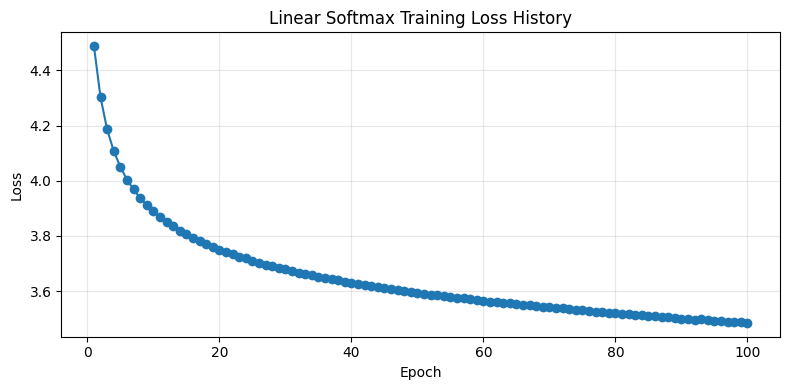

In [15]:
loss_hist = softmax_model.get("train_loss_history", [])
if len(loss_hist) == 0:
    raise ValueError("Chưa có train_loss_history.")

epochs = np.arange(1, len(loss_hist) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_hist, marker="o", linewidth=1.5)
plt.title("Linear Softmax Training Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Linear SVM

Phần này dùng `SGDClassifier(loss="hinge")` để huấn luyện mô hình SVM tuyến tính.

In [16]:
# Mô hình 3: Linear SVM
svm_model = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss="hinge",
        max_iter=1000,
        tol=1e-2,
        n_jobs=-1,
    ),
)
svm_model = train(svm_model, x_train, y_train)
y_pred_svm = predict(svm_model, x_test)

print("Linear SVM done")

Linear SVM done


## 5. Tổng hợp đánh giá

Bảng dưới đây tổng hợp `accuracy`, `f1`, `precision` cho 3 mô hình đã huấn luyện.

In [24]:
def evaluate(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = {
    "KNN (k=5)": evaluate(y_test, y_pred_knn_5),
    "KNN (k=7)": evaluate(y_test, y_pred_knn_7),
    "Linear Softmax": evaluate(y_test, y_pred_softmax),
    "Linear SVM": evaluate(y_test, y_pred_svm),
}

metrics_df = pd.DataFrame(results).T.round(4)
metrics_df

,accuracy,precision,f1
KNN (k=5),0.1504,0.2192,0.1424
KNN (k=7),0.1519,0.2118,0.1428
Linear Softmax,0.1763,0.1601,0.1540
Linear SVM,0.1535,0.1524,0.1485


d:\Code_learning\deepLearning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


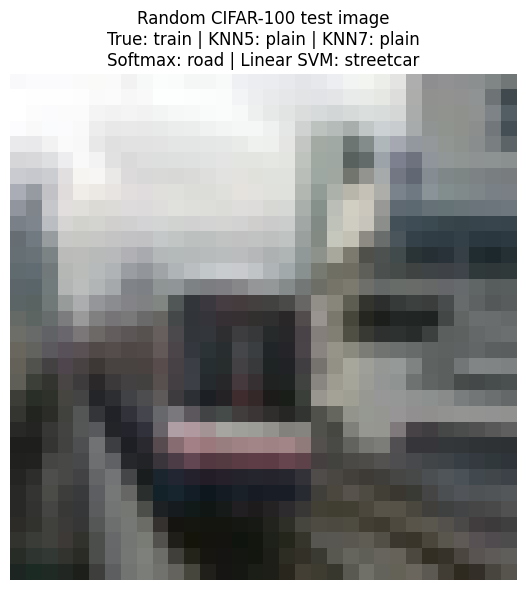

Index: 892
True label      : 90 -> train
KNN (k=5)       : 60 -> plain
KNN (k=7)       : 60 -> plain
Linear Softmax  : 68 -> road
Linear SVM      : 81 -> streetcar


In [25]:
# Demo: chọn ngẫu nhiên 1 ảnh test, hiển thị ảnh và so sánh dự đoán của 4 model
required_vars = [
    "x_test",
    "y_test",
    "knn_model_5",
    "knn_model_7",
    "softmax_model",
    "svm_model",
]

missing = [var_name for var_name in required_vars if var_name not in globals()]
if missing:
    raise ValueError(f"Thiếu biến trong kernel: {missing}. Hãy chạy lại các cell train trước.")

class_names = datasets.CIFAR100(root=DATA_DIR, train=True, download=False).classes

def label_to_name(label_index):
    return class_names[int(label_index)]

rng_vis = np.random.default_rng(RANDOM_STATE)
idx = int(rng_vis.integers(0, len(x_test)))

x_one = x_test[idx:idx + 1]
y_true_one = int(y_test[idx])

pred_knn5 = int(predict(knn_model_5, x_one)[0])
pred_knn7 = int(predict(knn_model_7, x_one)[0])
pred_softmax = int(predict(softmax_model, x_one)[0])
pred_svm = int(predict(svm_model, x_one)[0])

# x_test đang là ảnh flatten dạng (3072,), reshape lại về (32, 32, 3) để hiển thị
img = x_test[idx].reshape(32, 32, 3)
img = np.clip(img, 0.0, 1.0)

true_name = label_to_name(y_true_one)
pred_knn5_name = label_to_name(pred_knn5)
pred_knn7_name = label_to_name(pred_knn7)
pred_softmax_name = label_to_name(pred_softmax)
pred_svm_name = label_to_name(pred_svm)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    "Random CIFAR-100 test image\n"
    f"True: {true_name} | KNN5: {pred_knn5_name} | KNN7: {pred_knn7_name}\n"
    f"Softmax: {pred_softmax_name} | Linear SVM: {pred_svm_name}"
)
plt.tight_layout()
plt.show()

print(f"Index: {idx}")
print(f"True label      : {y_true_one} -> {true_name}")
print(f"KNN (k=5)       : {pred_knn5} -> {pred_knn5_name}")
print(f"KNN (k=7)       : {pred_knn7} -> {pred_knn7_name}")
print(f"Linear Softmax  : {pred_softmax} -> {pred_softmax_name}")
print(f"Linear SVM      : {pred_svm} -> {pred_svm_name}")